загрузка данных

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
import os
from pathlib import Path

In [83]:
if '__file__' in globals():
    current_dir = Path(__file__).parent
else:
    current_dir = Path.cwd()
    
project_root = current_dir.parent

df = pd.read_csv(os.path.join(project_root, 'data', 'batch_evaluation.csv'))

In [84]:
df['sources'] = df['sources'].apply(lambda x: eval(x) if isinstance(x, str) else x)
df['num_sources'] = df['sources'].apply(len)

df['category'] = df['category'].fillna('global')

In [85]:
df.head()

,query,architecture,answer,sources,category,confidence,processing_time,faithfulness,answer_relevancy,context_precision,num_sources
0,Прошу обновить данные о поверке счётчика в ЛКК,A,Прошу обновить информацию о поверке счётчика в...,"[train_70, obf_4606, obf_5789]",routine,0.7,6.639970,3.0,4.0,2.333333,3
1,Как настроить уведомления только о новых квита...,A,Для того чтобы настроить уведомления только о ...,"[train_113, train_87, obf_3847]",routine,0.7,40.585000,4.0,4.0,3.000000,3
2,При попытке скачать квитанцию выходит ошибка Ф...,B,"Извините, но в контексте, который вы предостав...","[train_22, obf_4416, train_102]",global,NaN,16.803998,3.0,3.0,3.200000,3
3,"Форма обратной связи не отправляется, бесконеч...",B,"Извините, но у меня нет достаточной информации...","[train_71, train_86, train_14]",global,NaN,30.216001,3.0,3.0,3.000000,3
4,Не загружается счёт-фактура за прошлый месяц,A,При возникновении проблемы с не загрузкой счет...,"[obf_1187, train_13, obf_1209]",routine,0.7,40.391000,4.0,4.0,2.000000,3


Корреляционная матрица

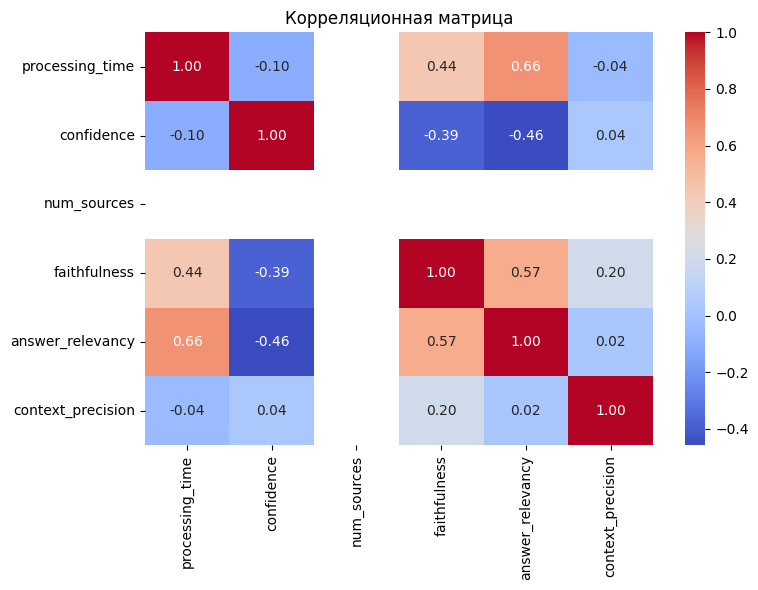

In [ ]:
numeric_cols = ['p_time', 'confidence', 'num_sources', 'faithfulness', 'answer_relevancy', 'context_precision']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.savefig('image/correlation_matrix.png', dpi=100)
plt.show()

Ящик с усами времени по архитектурам

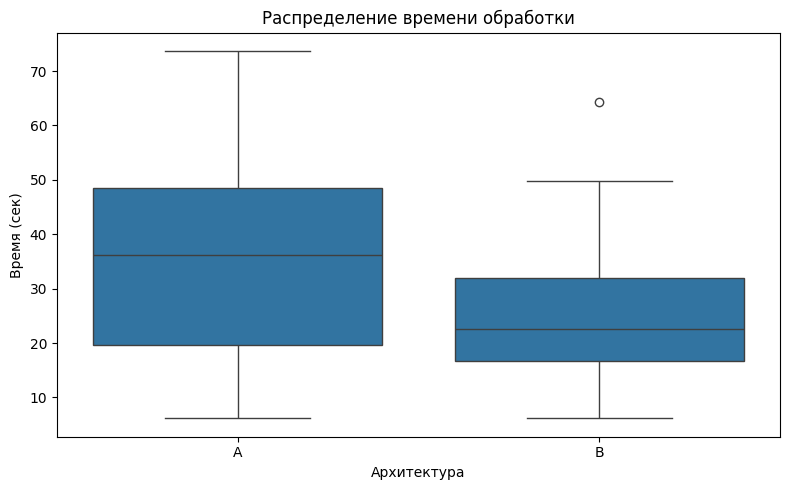

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='architecture', y='p_time', data=df)
plt.title('Распределение времени обработки')
plt.xlabel('Архитектура')
plt.ylabel('Время (сек)')
plt.tight_layout()
plt.savefig('image/time_boxplot.png')
plt.show()

Гистограммы времени

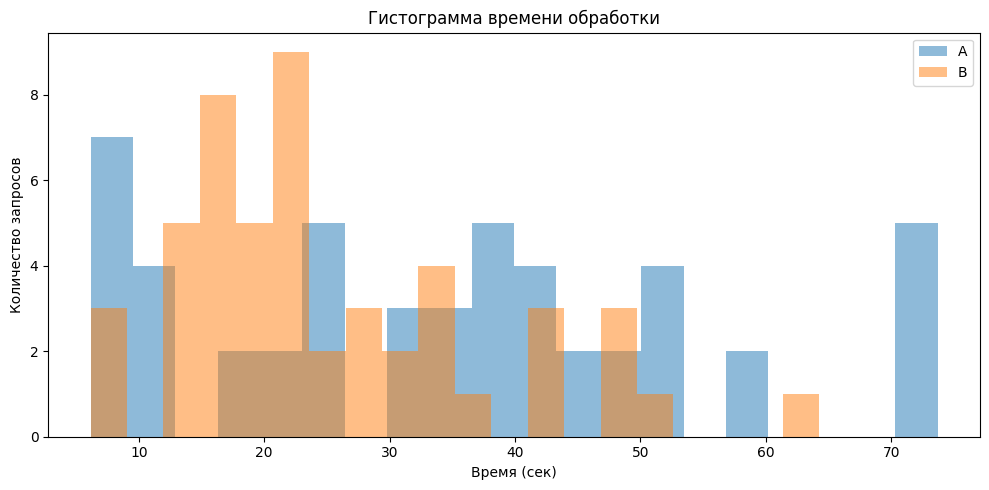

In [ ]:
plt.figure(figsize=(10,5))
for arch in ['A', 'B']:
    subset = df[df['architecture'] == arch]['p_time']
    plt.hist(subset, bins=20, alpha=0.5, label=arch)
plt.xlabel('Время (сек)')
plt.ylabel('Количество запросов')
plt.title('Гистограмма времени обработки')
plt.legend()
plt.tight_layout()
plt.savefig('image/time_hist.png')
plt.show()

Распределение 

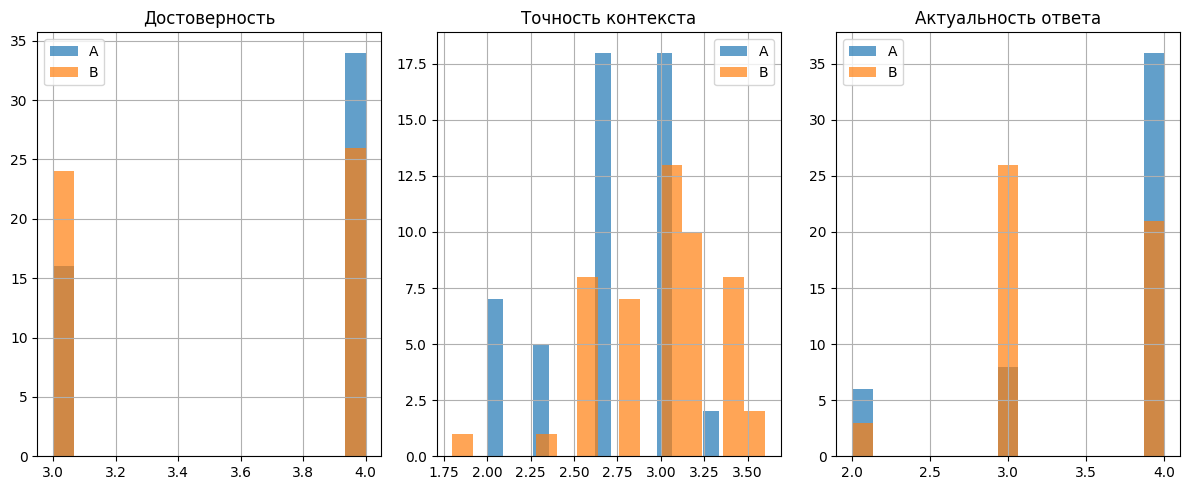

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Гистограмма для faithfulness
df[df['architecture'] == 'A']['faithfulness'].hist(ax=axes[0], alpha=0.7, bins=15, label='A')
df[df['architecture'] == 'B']['faithfulness'].hist(ax=axes[0], alpha=0.7, bins=15, label='B')
axes[0].set_title('Достоверность')
axes[0].legend()

# Гистограмма для context_precision
df[df['architecture'] == 'A']['context_precision'].hist(ax=axes[1], alpha=0.7, bins=15, label='A')
df[df['architecture'] == 'B']['context_precision'].hist(ax=axes[1], alpha=0.7, bins=15, label='B')
axes[1].set_title('Точность контекста')
axes[1].legend()

# Гистограмма для answer_relevancy
df[df['architecture'] == 'A']['answer_relevancy'].hist(ax=axes[2], alpha=0.7, bins=15, label='A')
df[df['architecture'] == 'B']['answer_relevancy'].hist(ax=axes[2], alpha=0.7, bins=15, label='B')
axes[2].set_title('Актуальность ответа')
axes[2].legend()

plt.tight_layout()
plt.savefig('image/quality_hist.png')
plt.show()

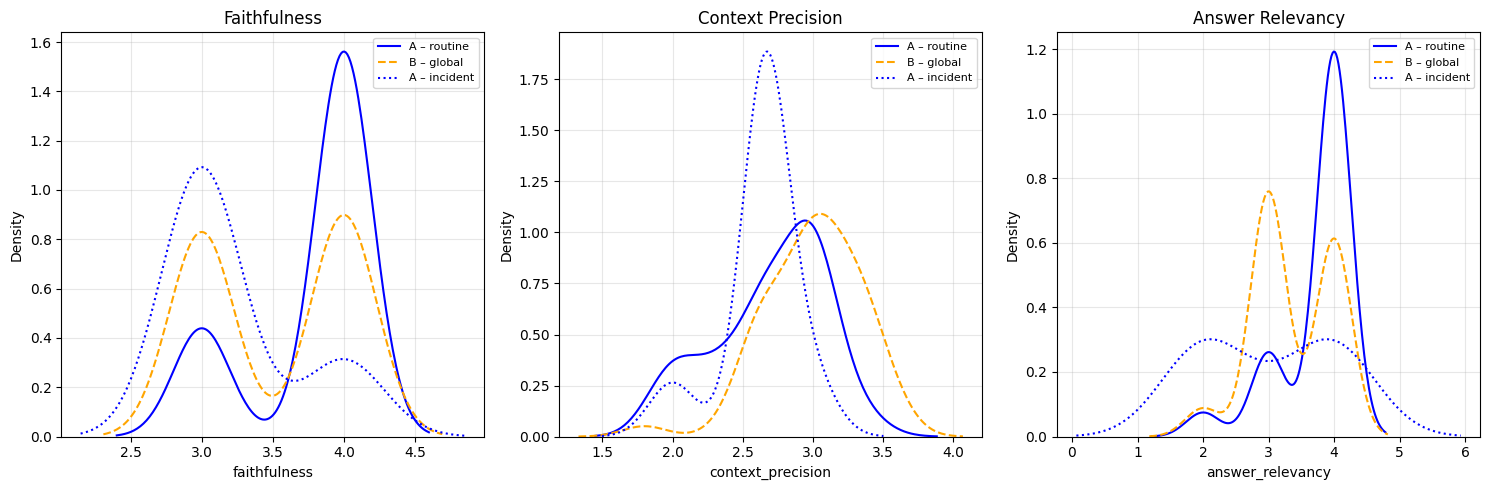

In [90]:
#Другое представление
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['faithfulness', 'context_precision', 'answer_relevancy']
titles = ['Faithfulness', 'Context Precision', 'Answer Relevancy']
categories = df['category'].unique()
linestyles = ['-', '--', ':']
colors = {'A': 'blue', 'B': 'orange'}

for i, (metric, title) in enumerate(zip(metrics, titles)):
    for cat, ls in zip(categories, linestyles):
        for arch in ['A', 'B']:
            data = df[(df['architecture'] == arch) & (df['category'] == cat)][metric]
            if not data.empty:
                sns.kdeplot(data=data, label=f'{arch} – {cat}', 
                            linestyle=ls, color=colors[arch], 
                            ax=axes[i], fill=False)
    axes[i].set_title(title)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('image/quality_den.png')
plt.show()